# Predict Customer Churn

![banner](./docs/assets/churn.png)

## Problem Statement

Customer churn — when a subscriber cancels their service — is costly to deal with after the fact. It's much cheaper to identify at-risk customers early and intervene proactively.

The dataset contains **594,194 telecom customers** with features covering contract type, payment method, internet services, and billing, along with a binary `Churn` label.

**Goal:** Build models that predict whether a customer will churn, then use **K-Means clustering** to engineer a customer segment feature and see if it improves performance.

**Models used:** Random Forest and XGBoost, evaluated before and after adding the cluster label.

In [1]:
import pandas as pd

churn_data = pd.read_csv("./data/customer_churn_train.csv")

churn_data = churn_data.set_index("id")

pd.set_option('display.max_columns', None)

churn_data.head()

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
id,,,,,,,,,,,,,,,,,,,,
0,Male,0,Yes,Yes,29,Yes,No,DSL,Yes,No,Yes,Yes,No,No,One year,Yes,Mailed check,60.10,1653.85,No
1,Male,0,Yes,Yes,58,Yes,No,DSL,Yes,Yes,No,Yes,Yes,No,Two year,No,Credit card (automatic),69.50,3778.20,No
2,Male,0,Yes,No,58,Yes,Yes,Fiber optic,No,Yes,No,No,Yes,Yes,Month-to-month,Yes,Electronic check,100.40,5841.35,No
3,Female,0,No,No,1,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,69.70,70.70,Yes
4,Female,0,No,No,1,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.45,70.45,Yes


## Understanding Data

In [2]:
churn_data.shape

(594194, 20)

In [3]:
churn_data.info()

<class 'pandas.DataFrame'>
RangeIndex: 594194 entries, 0 to 594193
Data columns (total 20 columns):
 #   Column            Non-Null Count   Dtype  
---  ------            --------------   -----  
 0   gender            594194 non-null  str    
 1   SeniorCitizen     594194 non-null  int64  
 2   Partner           594194 non-null  str    
 3   Dependents        594194 non-null  str    
 4   tenure            594194 non-null  int64  
 5   PhoneService      594194 non-null  str    
 6   MultipleLines     594194 non-null  str    
 7   InternetService   594194 non-null  str    
 8   OnlineSecurity    594194 non-null  str    
 9   OnlineBackup      594194 non-null  str    
 10  DeviceProtection  594194 non-null  str    
 11  TechSupport       594194 non-null  str    
 12  StreamingTV       594194 non-null  str    
 13  StreamingMovies   594194 non-null  str    
 14  Contract          594194 non-null  str    
 15  PaperlessBilling  594194 non-null  str    
 16  PaymentMethod     594194 non-nu

In [4]:
from pandas.api.types import is_string_dtype, is_object_dtype

features = churn_data.columns.drop('Churn')

categorical_cols = [col for col in features if is_object_dtype(churn_data[col]) or is_string_dtype(churn_data[col])]
numerical_cols = [col for col in features if col not in categorical_cols]

In [5]:
categorical_cols

['gender',
 'Partner',
 'Dependents',
 'PhoneService',
 'MultipleLines',
 'InternetService',
 'OnlineSecurity',
 'OnlineBackup',
 'DeviceProtection',
 'TechSupport',
 'StreamingTV',
 'StreamingMovies',
 'Contract',
 'PaperlessBilling',
 'PaymentMethod']

In [6]:
numerical_cols

['SeniorCitizen', 'tenure', 'MonthlyCharges', 'TotalCharges']

In [7]:
# Number of unique categorical values
churn_data[categorical_cols].nunique()

gender              2
Partner             2
Dependents          2
PhoneService        2
MultipleLines       3
InternetService     3
OnlineSecurity      3
OnlineBackup        3
DeviceProtection    3
TechSupport         3
StreamingTV         3
StreamingMovies     3
Contract            3
PaperlessBilling    2
PaymentMethod       4
dtype: int64

<Axes: title={'center': 'Customer Churn'}, xlabel='Churn', ylabel='count'>

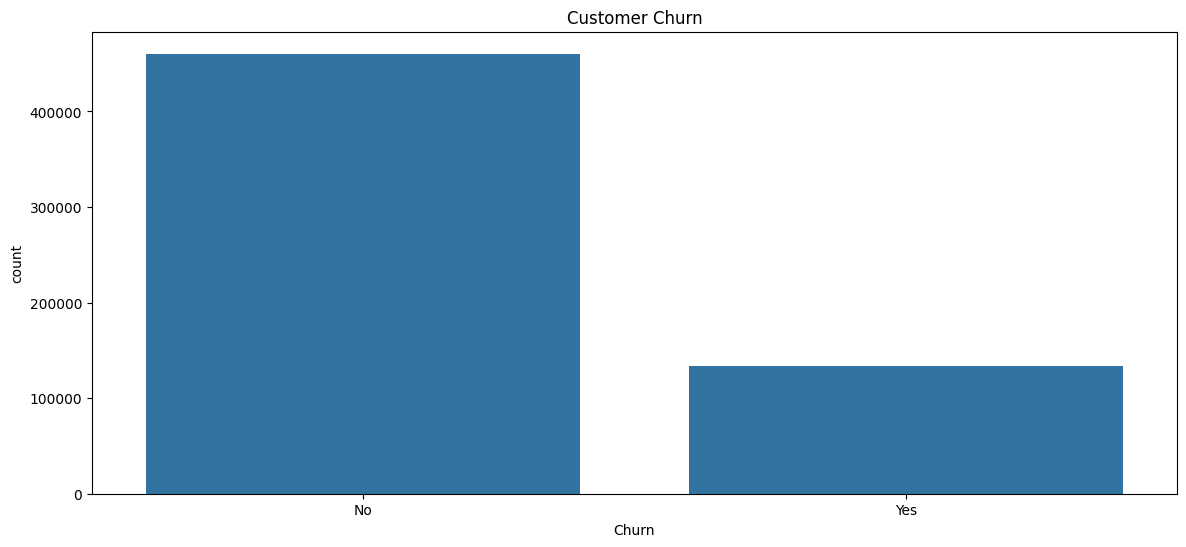

In [8]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(14,6))

plt.title("Customer Churn")

churn_count = churn_data['Churn'].value_counts().to_frame(name='count')
sns.barplot(x=churn_count.index, y=churn_count['count'])

## Feature Engineering

In [9]:
from sklearn.feature_selection import mutual_info_classif
import numpy as np

def make_mi_scores(X, y, discrete_features):
    mi_scores = mutual_info_classif(X, y, discrete_features=discrete_features)
    mi_scores = pd.Series(mi_scores, name="MI Scores", index=X.columns)
    mi_scores = mi_scores.sort_values(ascending=False)
    return mi_scores

def plot_mi_scores(scores):
    scores = scores.sort_values(ascending=True)
    width = np.arange(len(scores))
    ticks = list(scores.index)
    plt.barh(width, scores)
    plt.yticks(width, ticks)
    plt.title("Mutual Information Scores")

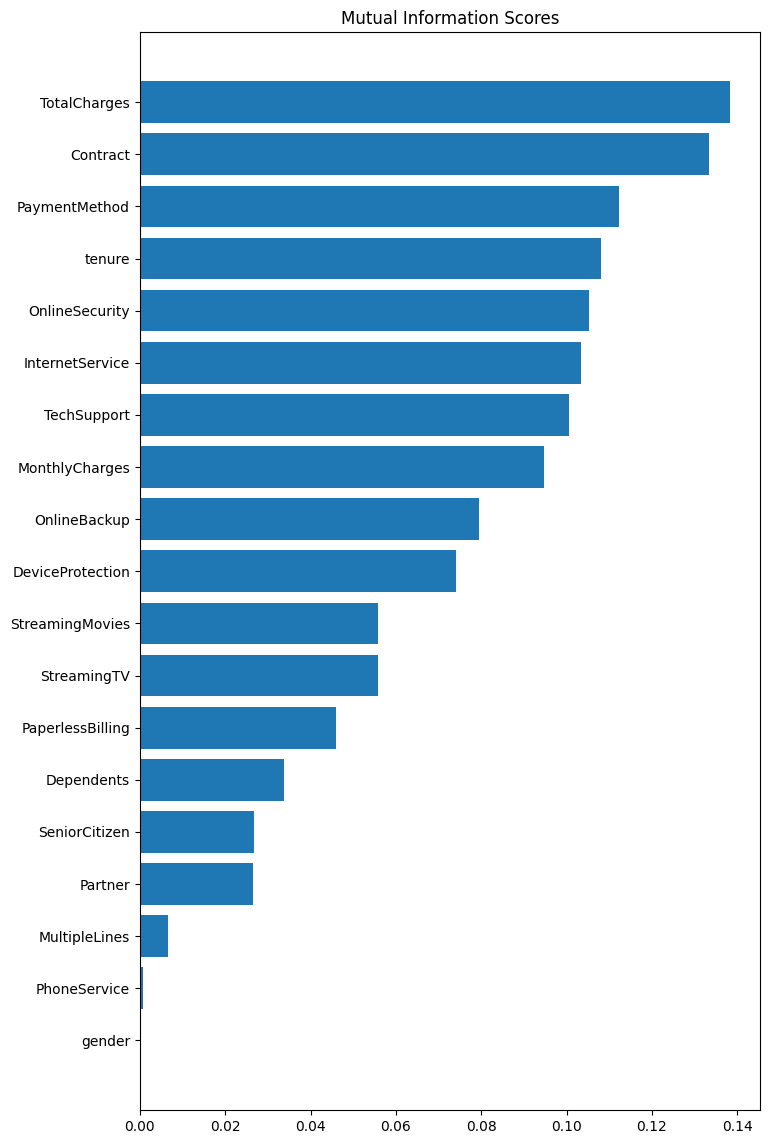

In [10]:
churn = churn_data["Churn"].map({"No": 0, "Yes": 1})

# Encode categoricals as integers (MI requires numeric input)
mi_data = churn_data[categorical_cols + numerical_cols].copy()
for col in categorical_cols:
    mi_data[col] = mi_data[col].astype('category').cat.codes

# True = discrete, False = continuous
discrete_mask = [True] * len(categorical_cols) + [False] * len(numerical_cols)

mi_scores = make_mi_scores(mi_data, churn, discrete_features=discrete_mask)

plt.figure(dpi=100, figsize=(8, 14))
plot_mi_scores(mi_scores)

<Axes: xlabel='Churn', ylabel='TotalCharges'>

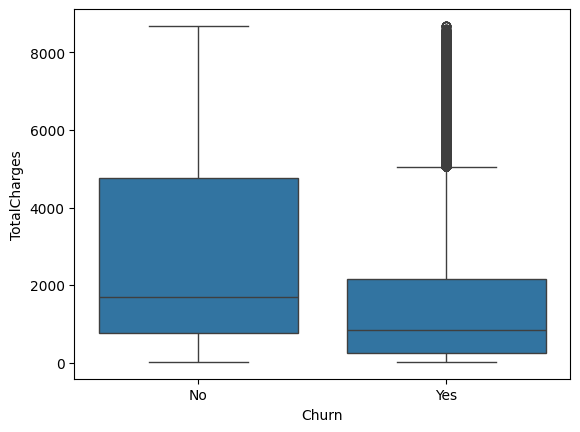

In [11]:
sns.boxplot(data=churn_data, x="Churn", y="TotalCharges")

💡 Customers with lower `TotalCharges` are more likely to churn, suggesting newer customers are at higher risk.

<Axes: xlabel='Churn', ylabel='tenure'>

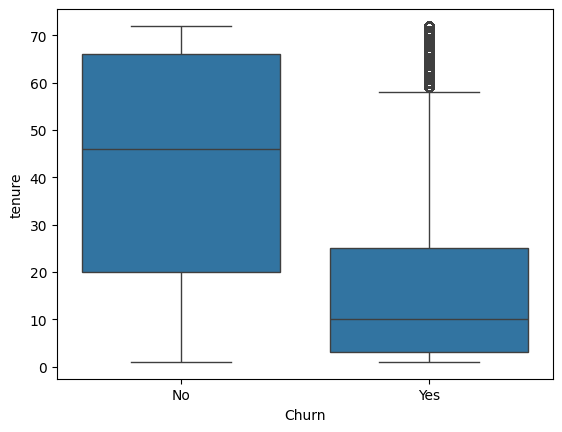

In [12]:
sns.boxplot(data=churn_data, x="Churn", y="tenure")

💡 `tenure` = number of months since the customer started the service
💡 customers with low tenure are much more likely to churn

<Axes: xlabel='Contract', ylabel='count'>

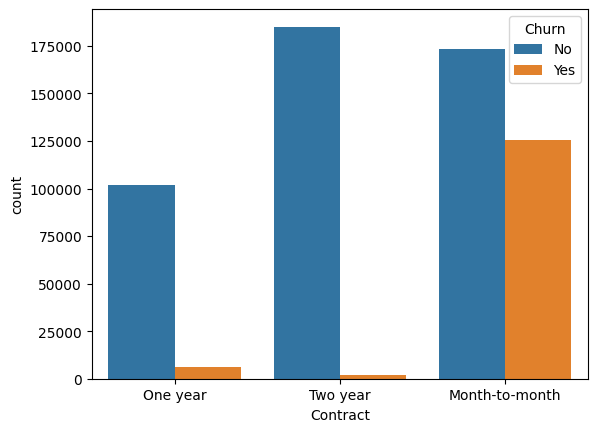

In [13]:
sns.countplot(data=churn_data, x="Contract", hue="Churn")

<Axes: xlabel='PaymentMethod', ylabel='count'>

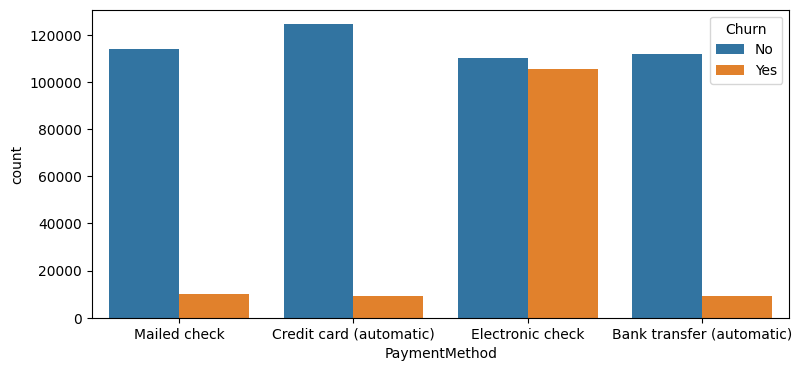

In [14]:
plt.figure(dpi=100, figsize=(9,4))

sns.countplot(data=churn_data, x="PaymentMethod", hue="Churn")

<Axes: xlabel='InternetService', ylabel='count'>

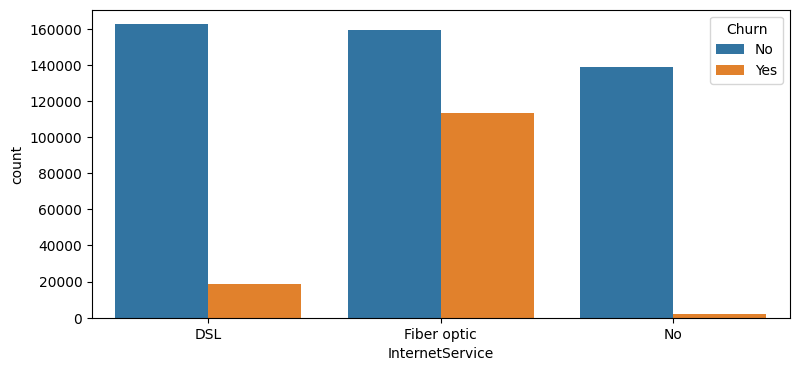

In [15]:
plt.figure(dpi=100, figsize=(9,4))

sns.countplot(data=churn_data, x="InternetService", hue="Churn")

<Axes: xlabel='TechSupport', ylabel='count'>

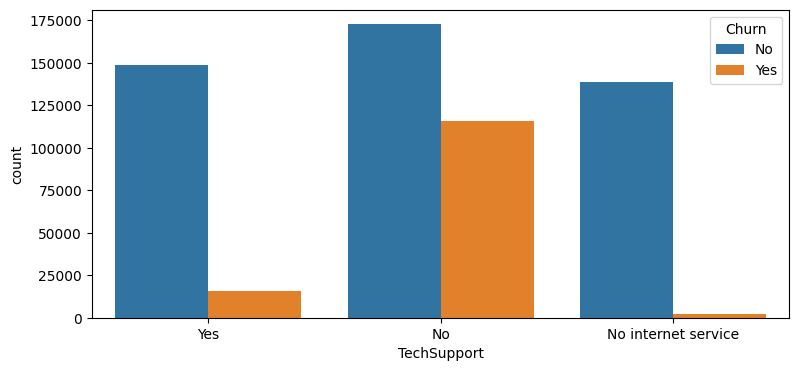

In [16]:
plt.figure(dpi=100, figsize=(9,4))

sns.countplot(data=churn_data, x="TechSupport", hue="Churn")

<Axes: xlabel='OnlineBackup', ylabel='count'>

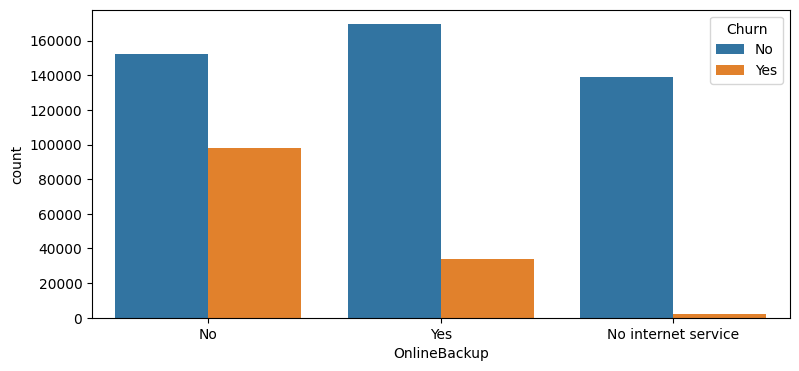

In [17]:
plt.figure(dpi=100, figsize=(9,4))

sns.countplot(data=churn_data, x="OnlineBackup", hue="Churn")

<Axes: xlabel='DeviceProtection', ylabel='count'>

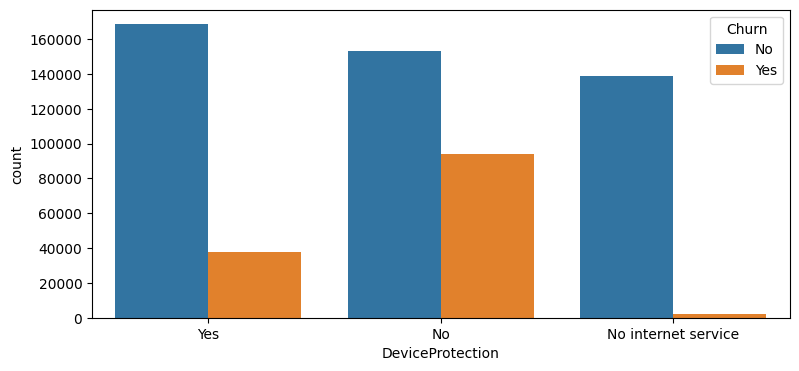

In [18]:
plt.figure(dpi=100, figsize=(9,4))

sns.countplot(data=churn_data, x="DeviceProtection", hue="Churn")

In [19]:
sel_cat_features = [
    'Contract',
    'PaymentMethod',
    'OnlineSecurity',
    'InternetService',
    'TechSupport',
    'OnlineBackup',
    'DeviceProtection'
]

sel_num_features = [
    'TotalCharges',
    'tenure',
    'MonthlyCharges'
]

## Pipeline

In [20]:
from sklearn.model_selection import train_test_split

train_X, val_X, train_y, val_y = train_test_split(churn_data[sel_cat_features+sel_num_features], churn, random_state=0, stratify=churn)

In [21]:
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder

numerical_transformer = SimpleImputer(strategy='median')

categorical_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('onehot', OneHotEncoder(handle_unknown='ignore')),
])

preprocessor = ColumnTransformer(
    transformers=[
        ('num', numerical_transformer, sel_num_features),
        ('cat', categorical_transformer, sel_cat_features)
    ]
)

### Random Forest

In [22]:
from sklearn.ensemble import RandomForestClassifier

forest_model = RandomForestClassifier(random_state=0, class_weight='balanced')

my_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('model', forest_model)
])

my_pipeline.fit(train_X, train_y)
pred = my_pipeline.predict(val_X)

In [23]:
from sklearn.metrics import classification_report, roc_auc_score

print(classification_report(val_y, pred))
print("ROC-AUC:", roc_auc_score(val_y, my_pipeline.predict_proba(val_X)[:, 1]))

              precision    recall  f1-score   support

           0       0.89      0.91      0.90    115095
           1       0.66      0.60      0.63     33454

    accuracy                           0.84    148549
   macro avg       0.77      0.75      0.76    148549
weighted avg       0.83      0.84      0.84    148549

ROC-AUC: 0.8869521839607373


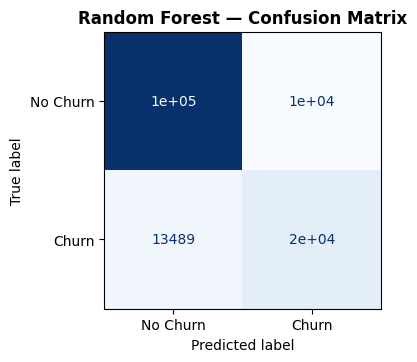

In [24]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

fig, ax = plt.subplots(figsize=(4, 4))
cm = confusion_matrix(val_y, my_pipeline.predict(val_X))
ConfusionMatrixDisplay(cm, display_labels=["No Churn", "Churn"]).plot(
    cmap="Blues", ax=ax, colorbar=False
)
ax.set_title("Random Forest — Confusion Matrix", fontweight="bold")
plt.tight_layout()
plt.show()

### XGBoost

In [25]:
from xgboost import XGBClassifier

xgboost_model = XGBClassifier(n_estimators=500, early_stopping_rounds=5)

my_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('model', xgboost_model)
])

my_pipeline.fit(train_X, train_y,
             model__eval_set=[(preprocessor.transform(val_X), val_y)],
             model__verbose=False)
pred = my_pipeline.predict(val_X)

In [26]:
print(classification_report(val_y, pred))
print("ROC-AUC:", roc_auc_score(val_y, my_pipeline.predict_proba(val_X)[:, 1]))

              precision    recall  f1-score   support

           0       0.90      0.92      0.91    115095
           1       0.70      0.64      0.67     33454

    accuracy                           0.86    148549
   macro avg       0.80      0.78      0.79    148549
weighted avg       0.85      0.86      0.86    148549

ROC-AUC: 0.9133763182466491


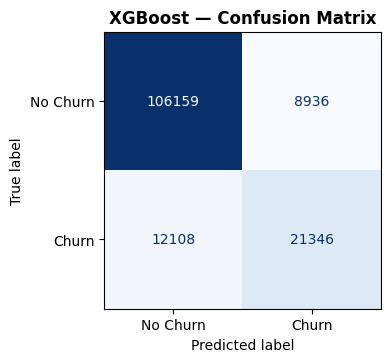

In [27]:
fig, ax = plt.subplots(figsize=(4, 4))
cm = confusion_matrix(val_y, pred)
ConfusionMatrixDisplay(cm, display_labels=["No Churn", "Churn"]).plot(
    cmap="Blues", ax=ax, colorbar=False
)
ax.set_title("XGBoost — Confusion Matrix", fontweight="bold")
plt.tight_layout()
plt.show()

## K-Means Clustering

The idea is to cluster customers into segments based on their numerical features (`TotalCharges`, `tenure`, `MonthlyCharges`) using K-Means, then pass the cluster label as an additional categorical feature into both classifiers.

The hypothesis is that customers in the same segment behave similarly, so knowing which group a customer belongs to might give the model a useful shortcut for predicting churn.

### Find Optimal K

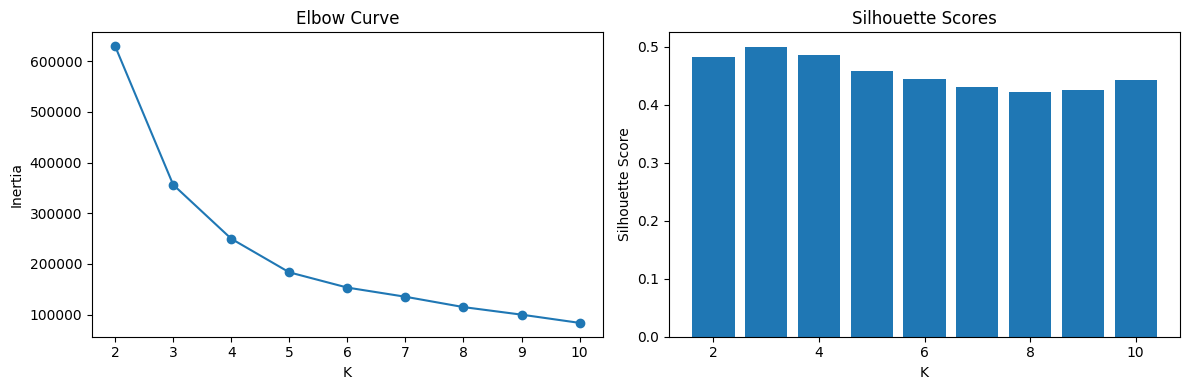

In [28]:
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(train_X[sel_num_features])

rng = np.random.default_rng(0)
sample_idx = rng.choice(len(X_train_scaled), size=10_000, replace=False)
X_sample = X_train_scaled[sample_idx]

inertias, sil_scores = [], []
K_range = range(2, 11)

for k in K_range:
    km = KMeans(n_clusters=k, random_state=0, n_init='auto')
    km.fit(X_train_scaled)
    inertias.append(km.inertia_)
    sil_scores.append(silhouette_score(X_sample, km.predict(X_sample)))

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

ax1.plot(K_range, inertias, marker='o')
ax1.set_xlabel('K')
ax1.set_ylabel('Inertia')
ax1.set_title('Elbow Curve')

ax2.bar(K_range, sil_scores)
ax2.set_xlabel('K')
ax2.set_ylabel('Silhouette Score')
ax2.set_title('Silhouette Scores')

plt.tight_layout()
plt.show()

The elbow curve flattens noticeably at K=3 and the silhouette score is reasonable there — adding more clusters beyond 3 gives diminishing returns. **K=3** is used going forward.

In [29]:
K = 3

kmeans = KMeans(n_clusters=K, random_state=0, n_init='auto')
kmeans.fit(X_train_scaled)

train_X = train_X.copy()
val_X = val_X.copy()
train_X['cluster'] = kmeans.predict(X_train_scaled).astype(str)
val_X['cluster'] = kmeans.predict(scaler.transform(val_X[sel_num_features])).astype(str)

print("Cluster distribution (train):")
print(train_X['cluster'].value_counts().sort_index())

Cluster distribution (train):
cluster
0    132539
1    170166
2    142940
Name: count, dtype: int64


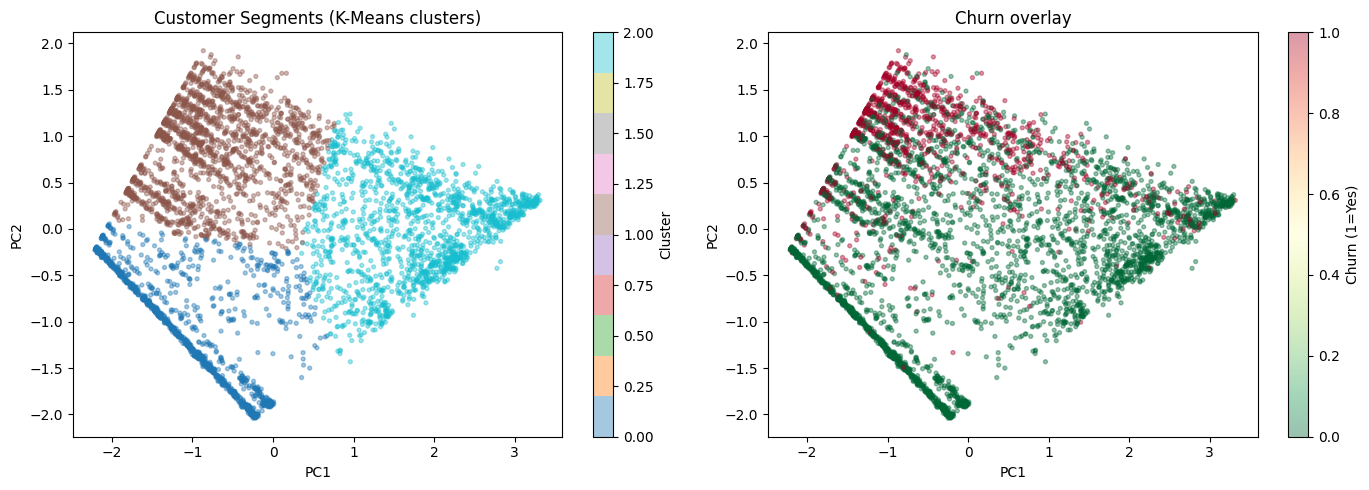

In [30]:
from sklearn.decomposition import PCA

pca = PCA(n_components=2, random_state=0)

rng = np.random.default_rng(0)
viz_idx = rng.choice(len(X_train_scaled), size=5_000, replace=False)
X_viz = pca.fit_transform(X_train_scaled[viz_idx])
clusters_viz = train_X['cluster'].values[viz_idx]
churn_viz = train_y.values[viz_idx]

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

scatter1 = ax1.scatter(X_viz[:, 0], X_viz[:, 1], c=clusters_viz.astype(int),
                       cmap='tab10', alpha=0.4, s=8)
ax1.set_title('Customer Segments (K-Means clusters)')
ax1.set_xlabel('PC1')
ax1.set_ylabel('PC2')
plt.colorbar(scatter1, ax=ax1, label='Cluster')

scatter2 = ax2.scatter(X_viz[:, 0], X_viz[:, 1], c=churn_viz,
                       cmap='RdYlGn_r', alpha=0.4, s=8)
ax2.set_title('Churn overlay')
ax2.set_xlabel('PC1')
ax2.set_ylabel('PC2')
plt.colorbar(scatter2, ax=ax2, label='Churn (1=Yes)')

plt.tight_layout()
plt.show()

### Re-train Models with Cluster Feature

In [31]:
sel_cat_features_with_cluster = sel_cat_features + ['cluster']

preprocessor_with_cluster = ColumnTransformer(
    transformers=[
        ('num', numerical_transformer, sel_num_features),
        ('cat', categorical_transformer, sel_cat_features_with_cluster)
    ]
)

forest_model_v2 = RandomForestClassifier(random_state=0, class_weight='balanced')

pipeline_rf_cluster = Pipeline(steps=[
    ('preprocessor', preprocessor_with_cluster),
    ('model', forest_model_v2)
])

pipeline_rf_cluster.fit(train_X, train_y)
pred_rf_v2 = pipeline_rf_cluster.predict(val_X)

print("Random Forest + cluster  (baseline ROC-AUC: 0.8870)")
print(classification_report(val_y, pred_rf_v2))
print("ROC-AUC:", roc_auc_score(val_y, pipeline_rf_cluster.predict_proba(val_X)[:, 1]))

Random Forest + cluster  (baseline ROC-AUC: 0.8870)
              precision    recall  f1-score   support

           0       0.89      0.91      0.90    115095
           1       0.66      0.60      0.63     33454

    accuracy                           0.84    148549
   macro avg       0.77      0.75      0.76    148549
weighted avg       0.83      0.84      0.84    148549

ROC-AUC: 0.8866167145336594


In [32]:
xgboost_model_v2 = XGBClassifier(n_estimators=500, early_stopping_rounds=5)

pipeline_xgb_cluster = Pipeline(steps=[
    ('preprocessor', preprocessor_with_cluster),
    ('model', xgboost_model_v2)
])

pipeline_xgb_cluster.fit(
    train_X, train_y,
    model__eval_set=[(preprocessor_with_cluster.transform(val_X), val_y)],
    model__verbose=False
)
pred_xgb_v2 = pipeline_xgb_cluster.predict(val_X)

print("XGBoost + cluster  (baseline ROC-AUC: 0.9134)")
print(classification_report(val_y, pred_xgb_v2))
print("ROC-AUC:", roc_auc_score(val_y, pipeline_xgb_cluster.predict_proba(val_X)[:, 1]))

XGBoost + cluster  (baseline ROC-AUC: 0.9134)
              precision    recall  f1-score   support

           0       0.90      0.92      0.91    115095
           1       0.71      0.64      0.67     33454

    accuracy                           0.86    148549
   macro avg       0.80      0.78      0.79    148549
weighted avg       0.85      0.86      0.86    148549

ROC-AUC: 0.9135847039919064


## Conclusion

### Results Summary

| Model | Baseline ROC-AUC | With Cluster ROC-AUC |
|---|---|---|
| Random Forest | 0.8870 | 0.8866 |
| XGBoost | 0.9134 | 0.9136 |

### Did K-Means help?

The cluster feature made very little difference — XGBoost improved by 0.0002 and Random Forest dropped slightly. This isn't too surprising: the features used for clustering (`TotalCharges`, `tenure`, `MonthlyCharges`) are already in the model, so the cluster label isn't adding much on top of what both models can already learn directly from those features.

That said, the PCA visualisation shows the three segments have a reasonable overlap with churn rate, which is useful for understanding the customer base even if it doesn't move the metrics much.

### Key findings from EDA

- Customers on **month-to-month contracts** churn far more than those on annual or two-year plans.
- Low `tenure` and low `TotalCharges` are the strongest predictors — newer customers are at much higher risk.
- Customers paying by **electronic check** churn more than those on automatic payment methods.

### Limitations

- The cluster feature was derived from features already present in the model, limiting its potential uplift.
- Only numerical features were used for clustering — including categorical features could produce more meaningful segments.
- No hyperparameter tuning was done on either baseline model; there's likely room to improve further.